# Machine Learning for Physicists: Hello ~~World~~ Neural Networks

Last time you were introduced to the world of [JAX](https://docs.jax.dev/en/latest/) by learning how JAX leverages *autodifferentiation* to compute gradients - **the** key compotent for local **optimisation**. With easy access to gradients it becomes simple to fit complicated and convoluted functions to abstract data, which is basically the definition of machine learning. 

## Goal of this tutorial

At the end of this tutorial, you should be leaving with an idea how a simple "dense neural network" can be implemented in JAX and how the training of such a network works. We will be using our own implementation to drive the principles home - in practice one would use premade libraries to build Neural networks rather than build them from scratch. 

By far the simplest model that can be seen as machine learning is the 

 $$\mathrm{Perceptron} $$

a single layer neural network. The larger brother, the multi-layer Perceptron is still around and you will see the abbreviation "MLP" appear from time to time in practice.

The function of the Perceptron is given by 
$$ y(x) = f_{\mathrm{NL}}\Bigl(\sum_{j=0}^N w_{ij} \cdot x_{j} + b_i \Bigr) $$

where $f_{\mathrm{NL}}$ denotes some non-linear function (e.g. Sigmoid, Tanh or ReLU).

## Data

But before implementing the Perceptron lets briefly look at some data. A typical collection of data could look similar like below with two different *features* of the data $x_1$ and $x_2$ that were measured. (E.g. voltage and current of some devices or the wingspan and beak-lenght of birds.) Assume you know that there are two different *types* of classes that have the feature and you would like to distinguish the two. 

How would you do that? 

Play around with the sliders below!

In [ ]:
from ipywidgets import FloatSlider, interactive_output, VBox
from IPython.display import display, clear_output

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

key = jax.random.key(0)
key_a, key_b = jax.random.split(key)

n_per_class = 100

mean_a = jnp.array([-1.0, -2.0])
mean_b = jnp.array([2.0, 1.0])
cov_scale = 0.7

x_a = mean_a + cov_scale * jax.random.normal(key_a, (n_per_class, 2))
x_b = mean_b + cov_scale * jax.random.normal(key_b, (n_per_class, 2))

X = jnp.concatenate([x_a, x_b], axis=0)
Y = jnp.concatenate([jnp.zeros(n_per_class), jnp.ones(n_per_class)])


# grid for evaluating the decision function on the whole plane
xx, yy = jnp.meshgrid(jnp.linspace(-5, 5, 200), jnp.linspace(-5, 5, 200))
grid = jnp.stack([xx.ravel(), yy.ravel()], axis=1)

def plot_boundary(w1, w2, b):
    clear_output(wait=True)
    # decision function: sigmoid(w1*x1 + w2*x2 + b) -- the perceptron
    z = grid @ jnp.array([w1, w2]) + b
    p = jax.nn.sigmoid(z).reshape(xx.shape)

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.contourf(xx, yy, p, levels=20, cmap="RdBu_r", alpha=0.6)
    ax.contour(xx, yy, p, levels=[0.5], colors="k", linewidths=2)
    ax.scatter(x_a[:, 0], x_a[:, 1], c="tab:blue", label="class 0", edgecolor="k")
    ax.scatter(x_b[:, 0], x_b[:, 1], c="tab:orange", label="class 1", edgecolor="k")
    ax.set_xlim(-5, 5)
    ax.set_ylim(-5, 5)
    ax.set_xlabel("Feature $x_1$")
    ax.set_ylabel("Feature $x_2$")
    ax.set_aspect("equal")
    ax.set_title(f"$\\sigma(w_1 x_1 + w_2 x_2 + b)$  with  $w_1={w1:.2f},\\ w_2={w2:.2f},\\ b={b:.2f}$")
    ax.legend(loc="upper left")
    plt.show()
    plt.close(fig)

w1 = FloatSlider(min=-5.0, max=5.0, step=0.01, value=0.0, description="w1")
w2 = FloatSlider(min=-5.0, max=5.0, step=0.01, value=0.1, description="w2")
b  = FloatSlider(min=-5.0, max=5.0, step=0.01, value=0.0, description="b")
out = interactive_output(plot_boundary, {"w1": w1, "w2": w2, "b": b})
display(VBox([w1, w2, b, out]))

The goal is now to automate the task to find the best separation between the two classes. We will use a Perceptron to do the task for us!

Your goal is to implement this Perceptron with JAX and learn the descision boundary. 

Before jumping in think about:
- What are the inputs and outputs of this Perceptron?
- What does the loss function need to do for the Perceptron to properly optimise? 
- How do you do the optimisation? Specifically
    - How to compute the gradients with JAX? 
    - How do you update the parameters? 

In [ ]:
# single perceptron: 2 inputs -> 1 output

def forward(W, b, x):
    # TODO
    pass

def f_loss():
    # TODO
    pass

# initialise the weights
key = jax.random.key(0)
W = 0.5 * jax.random.normal(key, (2,))
b = 0.0

# gradients 
grad_f = None # TODO


lr = 0.5
losses = []
for step in range(1000):
    # compute loss
    current_loss = f_loss() # TODO # the data X and targets Y are defined in the previous cell
    losses.append(float(current_loss))
    if current_loss < 0.001:
        break

    # compute gradients
    # TODO

    # update each parameter
    # TODO

print(f"final loss: {losses[-1]:.4f}")
print(f"W = {W}, b = {b:.3f}")

print(f"final loss: {losses[-1]:.4f}")
print(f"W = {W}, b = {b:.3f}")


######################################################
# --------------------- Plotting ---------------------
######################################################


xx, yy = jnp.meshgrid(jnp.linspace(-5, 5, 200), jnp.linspace(-5, 5, 200))
grid = jnp.stack([xx.ravel(), yy.ravel()], axis=1)
probs = forward(W, b, grid).reshape(xx.shape)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.plot(losses)
ax1.set_xlabel("step")
ax1.set_ylabel("loss")
ax1.set_title("training loss")

ax2.contourf(xx, yy, probs, levels=20, cmap="RdBu_r", alpha=0.6)
ax2.contour(xx, yy, probs, levels=[0.5], colors="k", linewidths=2)
ax2.scatter(x_a[:, 0], x_a[:, 1], c="tab:blue", label="class 0", edgecolor="k")
ax2.scatter(x_b[:, 0], x_b[:, 1], c="tab:orange", label="class 1", edgecolor="k")
ax2.set_aspect("equal")
ax2.set_title("decision boundary")
ax2.legend(loc="upper left")
plt.show()

## Part 2

Nice, you have found the decision boundary - but this was a simple case. The data was *linearly separable*, a special and particularly easy situation because a linear decision boundary can split the two classes cleanly.

What happens in the next situation where the data is intertwined as shown below? How could it become possible to separate the data with a Perceptron? 

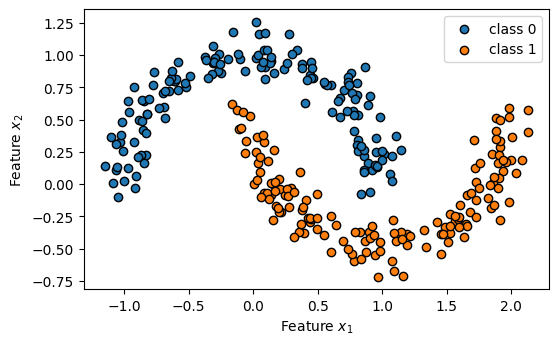

In [125]:
# two moons: a dataset that is NOT linearly separable

key = jax.random.key(1)
k_theta_a, k_theta_b, k_noise_a, k_noise_b = jax.random.split(key, 4)

n_per_class = 150
noise = 0.1

# upper moon: half circle from theta = 0 .. pi
theta_a = jax.random.uniform(k_theta_a, (n_per_class,), minval=0.0, maxval=jnp.pi)
x_moon_a = jnp.stack([jnp.cos(theta_a), jnp.sin(theta_a)], axis=1)
x_moon_a = x_moon_a + noise * jax.random.normal(k_noise_a, x_moon_a.shape)

# lower moon: flipped half circle, shifted to interlock with the upper one
theta_b = jax.random.uniform(k_theta_b, (n_per_class,), minval=0.0, maxval=jnp.pi)
x_moon_b = jnp.stack([1.0 - jnp.cos(theta_b), 0.5 - jnp.sin(theta_b)], axis=1)
x_moon_b = x_moon_b + noise * jax.random.normal(k_noise_b, x_moon_b.shape)

X_moons = jnp.concatenate([x_moon_a, x_moon_b], axis=0)
Y_moons = jnp.concatenate([jnp.zeros(n_per_class), jnp.ones(n_per_class)])

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(x_moon_a[:, 0], x_moon_a[:, 1], c="tab:blue", label="class 0", edgecolor="k")
ax.scatter(x_moon_b[:, 0], x_moon_b[:, 1], c="tab:orange", label="class 1", edgecolor="k")
ax.set_xlabel("Feature $x_1$")
ax.set_ylabel("Feature $x_2$")
ax.set_aspect("equal")
ax.legend()
plt.show()

In [ ]:
def forward():# TODO
    # TODO
    pass

def f_loss(): # TODO
    # TODO 
    pass

# initialise the weights
key = jax.random.key(0)
# TODO


# gradients 
grad_f = None # TODO


lr = 0.5
losses = []
for step in range(1000):
    # compute loss
    # use the new X_moons and Y_moons data varaiables here for the non-separable case
    current_loss = f_loss() # TODO # the data X_moons and targets Y_moons are defined in the previous cell
    losses.append(float(current_loss))
    if current_loss < 0.001:
        break

    # compute gradients
    # TODO

    # update each parameter
    # TODO

print(f"final loss: {losses[-1]:.4f}")


######################################################
# --------------------- Plotting ---------------------
######################################################


xx, yy = jnp.meshgrid(jnp.linspace(-2, 3, 200), jnp.linspace(-2, 2, 200))
grid = jnp.stack([xx.ravel(), yy.ravel()], axis=1)
probs = forward(W1, W2, b1, b2, grid).reshape(xx.shape)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.plot(losses)
ax1.set_xlabel("step")
ax1.set_ylabel("loss")
ax1.set_title("training loss")

ax2.contourf(xx, yy, probs, levels=20, cmap="RdBu_r", alpha=0.6)
ax2.contour(xx, yy, probs, levels=[0.5], colors="k", linewidths=2)
ax2.scatter(x_moon_a[:, 0], x_moon_a[:, 1], c="tab:blue", label="class 0", edgecolor="k")
ax2.scatter(x_moon_b[:, 0], x_moon_b[:, 1], c="tab:orange", label="class 1", edgecolor="k")
ax2.set_aspect("equal")
ax2.set_title("decision boundary")
ax2.legend(loc="upper left")
plt.show()

## Part 3 - Smile!

Neural networks are *universal function approximators*. Similarly as you can express any function with arbitrary precision by a Fourier- or Taylor series, you can express any function with a sufficiently large neural network. So lets learn to map a Smiley face :) 

Image shape:  (194, 194)


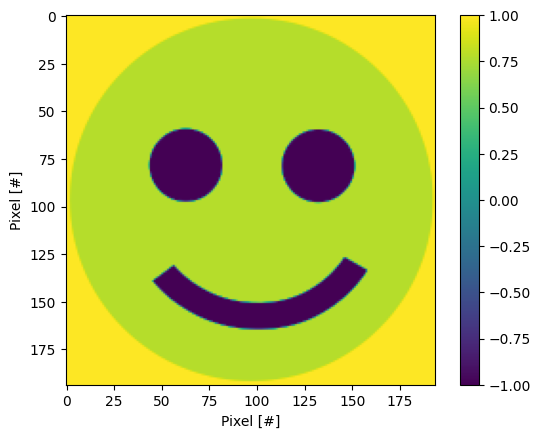

In [126]:
import imageio.v3 as iio

face = iio.imread('Smiley.png')
pixel_image = face[:,:,0]
pixel_image -= pixel_image.min()
pixel_image = (2*pixel_image.astype(dtype='float'))/pixel_image.max() - 1.0 # normalize between -1 and 1!

print("Image shape: ", pixel_image.shape)

cbar = plt.imshow(pixel_image)
plt.colorbar(cbar)
plt.xlabel("Pixel [#]")
plt.ylabel("Pixel [#]")
plt.show()

For this task, we now use the functions for a NN from the [lecture notebooks](https://florianmarquardt.github.io/MachineLearningThreeEasyLessons/2024_09_CurveFittingViaNeuralNetwork.html). 


In [ ]:
def NN(x, params):
    """
    Standard multilayer perception "MLP" with params['weights'] and params['biases'],
    applied to input vector x. Activation tanh applied to all
    layers except last.
    
    Returns activation vector of the output layer.
    """
    num_layers=len(params['weights'])
    for layer_idx, (w, b) in enumerate(zip(params['weights'],params['biases'])):
        x = jnp.matmul(w,x) + b
        if layer_idx < num_layers-1:
            x = jax.nn.relu( x )
    return x



def NN_init_params(key, num_neurons_layers):
    """
    Given a jax random key and a list of the neuron numbers
    in the layers of a network (simple fully connected network,
    i.e. 'multi-layer perceptron'), return a dictionary
    with the weights initialized randomly and biases set to zero.
    
    Returns: params, with params['weights'] a list of matrices and
    params['biases'] a list of vectors.
    """
    params = {}
    params['weights'] = []
    params['biases'] = []
    
    for lower_layer, higher_layer in zip( num_neurons_layers[:-1], num_neurons_layers[1:] ):
        key,subkey = jax.random.split( key )
        params['weights'].append( jax.random.normal( subkey,
                                        [higher_layer,lower_layer] ) /  
                                 jnp.sqrt( lower_layer ) )
        
    for num_neurons in num_neurons_layers[1:]:
        params['biases'].append( jnp.zeros( num_neurons) )
    
    return params

The image has 196x196 pixels and we want to compute the loss for each (pixel coordinates, pixel value) pair. 

Doing this in a for-loop is very inefficient --> parallelisation via [jax.vmap](https://docs.jax.dev/en/latest/_autosummary/jax.vmap.html).

Functions that are trivial to parallise (i.e. where every individual application of the function is independent) can be executed in parallel via the vmap function. All samples which are processed in parallel are concatenated in a new dimension of the data. This is the **batch-dimension**. The *batch* is a central concept in machine learning and is the collection of samples that are processed in parallel - you will hear this term frequently. 


Some hints: 
|`in_axes` per arg | meaning |
| -------------- | -------------- |
|`0`	|first axis is the batch axis — iterate over it |
|`n`	|nth axis is the batch axis |
|`None` |	not batched — share this value across all calls |
|`(0,2,None)`	|0 & 1 are the batch axis, share 2 across all calls |



In [ ]:
batched_NN = None # TODO

Manual managing updates of the parameters becomes error prone -> better: use [optax](https://optax.readthedocs.io/en/latest/getting_started.html#basic-usage-of-optax)

In [ ]:
from tqdm import tqdm # nice progress bars in for-loops
import optax

key = jax.random.key( 45 )

# number of neurons in each hidden layer:
num_hidden_1 = 300 
num_hidden_2 = 250

subkey, key = jax.random.split(key)
params = NN_init_params( subkey, [2, num_hidden_1, num_hidden_2, 1] )



lr = 0.001
optimiser = None # TODO
opt_state = optimiser.init(params)

Lets put everything together and create a training loop that actually learns to predict a smiley face

In [ ]:


# build training data: (row, col) pixel coordinates -> pixel intensity
H, W = pixel_image.shape
rr, cc = jnp.meshgrid(jnp.linspace(-1, 1, H), jnp.linspace(-1, 1, W), indexing="ij")
X_img = jnp.stack([rr.ravel(), cc.ravel()], axis=1).astype(jnp.float32)
Y_img = jnp.asarray(pixel_image.ravel(), dtype=jnp.float32)



# create
def f_loss(params, x, y):
    pred = batched_NN(x, params).squeeze(-1)
    return None # TODO

grad_f = None # TODO


losses = []
for i in tqdm(range(1000)):
    # compute loss
    current_loss = f_loss(params, X_img, Y_img)
    losses.append(float(current_loss))

    grads = grad_f(params, X_img, Y_img)

    # compute the update and the new state of the optimiser
    updates, opt_state = None # TODO

    # now actually update the weights and bias parameters
    params = None # TODO


print(f"final loss: {losses[-1]:.4f}")


######################################################
# --------------------- Plotting ---------------------
######################################################


pred_image = batched_NN(X_img, params).reshape(H, W)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))
ax1.plot(losses)
ax1.set_xlabel("step")
ax1.set_ylabel("loss")
ax1.set_title("training loss")
ax1.set_yscale("log")

ax2.imshow(pixel_image, cmap="viridis", vmin=-1, vmax=1)
ax2.set_title("target")
ax2.axis("off")

ax3.imshow(pred_image, cmap="viridis", vmin=-1, vmax=1)
ax3.set_title("NN prediction")
ax3.axis("off")
plt.show()

## Bonus task

Save intermediate results of the output during training and create a .gif that shows how the output of the network evolves over the training